In [7]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np

# 读取文件内容
file_path = '/home/aiqihang.aqh/R1-V-Action/R1-V/src/logs/train_stage1_stage2_0726.log'  # 替换成你的文件路径
with open(file_path, 'r') as file:
    lines = file.readlines()


all_json_data = []

for line in lines:
    try:
        all_json_data.append(json.loads(line.strip().replace('\'','"')))
    except:
        continue



all_json_data[0]

{'loss': -0.0108,
 'grad_norm': 3.5159569760841727,
 'learning_rate': 1e-06,
 'completion_length': 60.296875,
 'rewards/accuracy_reward': 1.0626229047775269,
 'rewards_zero_ratio/accuracy_reward': 0.0,
 'rewards_one_ratio/accuracy_reward': 0.5,
 'rewards/format_reward': 1.0,
 'rewards_zero_ratio/format_reward': 0.0,
 'rewards_one_ratio/format_reward': 1.0,
 'reward': 2.062622904777527,
 'reward_std': 0.18758251518011093,
 'kl': 0.0,
 'epoch': 0.0}

In [8]:
all_reward_data = [data for data in all_json_data if "loss" in data]

all_reward_data

from collections import OrderedDict
from statistics import mean

# 假设all_reward_data是你的列表
epoch_to_rewards = OrderedDict()

for item in all_reward_data:
    epoch = item['epoch']
    reward = item['reward']
    if epoch not in epoch_to_rewards:
        epoch_to_rewards[epoch] = []
    epoch_to_rewards[epoch].append(reward)

# 输出epoch和对应平均reward
# for epoch, rewards in epoch_to_rewards.items():
#     avg_reward = sum(rewards) / len(rewards)
#     print(f"epoch: {epoch}, avg_reward: {avg_reward}")


avg_reward_per_epoch = [
    {'epoch': epoch, 'avg_reward': sum(rewards) / len(rewards)}
    for epoch, rewards in epoch_to_rewards.items()
]
avg_reward_per_epoch


[{'epoch': 0.0, 'avg_reward': 2.062622904777527},
 {'epoch': 0.01, 'avg_reward': 1.94921875},
 {'epoch': 0.02, 'avg_reward': 2.0528688579797745},
 {'epoch': 0.03, 'avg_reward': 1.9766760393977165},
 {'epoch': 0.04, 'avg_reward': 2.1197916666666665},
 {'epoch': 0.05, 'avg_reward': 2.1006531715393066},
 {'epoch': 0.06, 'avg_reward': 2.153834715485573},
 {'epoch': 0.07, 'avg_reward': 2.1640625},
 {'epoch': 0.08, 'avg_reward': 2.0729166666666665},
 {'epoch': 0.09, 'avg_reward': 2.063292980194092},
 {'epoch': 0.1, 'avg_reward': 2.033203125},
 {'epoch': 0.11, 'avg_reward': 2.15625},
 {'epoch': 0.12, 'avg_reward': 2.0509159862995148},
 {'epoch': 0.13, 'avg_reward': 2.17578125},
 {'epoch': 0.14, 'avg_reward': 2.1193190217018127},
 {'epoch': 0.15, 'avg_reward': 2.1436678767204285},
 {'epoch': 0.16, 'avg_reward': 2.0751396864652634},
 {'epoch': 0.17, 'avg_reward': 2.154296875},
 {'epoch': 0.18, 'avg_reward': 2.055477999150753},
 {'epoch': 0.19, 'avg_reward': 2.125593662261963},
 {'epoch': 0.2, '

In [33]:
len(avg_reward_per_epoch)

201

In [14]:
group_size = 3            # 多少个聚为一组
N = len(avg_reward_per_epoch)
new_avg_reward_per_epoch = []

for i in range(0, N, group_size):
    group = avg_reward_per_epoch[i : i + group_size]
    # 聚合epoch与reward（epoch取均值，也可取第一个/最后一个）
    avg_epoch = np.mean([e['epoch'] for e in group])
    avg_reward = np.mean([e['avg_reward'] for e in group])
    new_avg_reward_per_epoch.append({'epoch': avg_epoch, 'avg_reward': avg_reward})

# 查看新列表长度
print(len(new_avg_reward_per_epoch))  # 应为 67

67


In [15]:
new_avg_reward_per_epoch = new_avg_reward_per_epoch[:-1]

In [16]:
len(new_avg_reward_per_epoch)

66

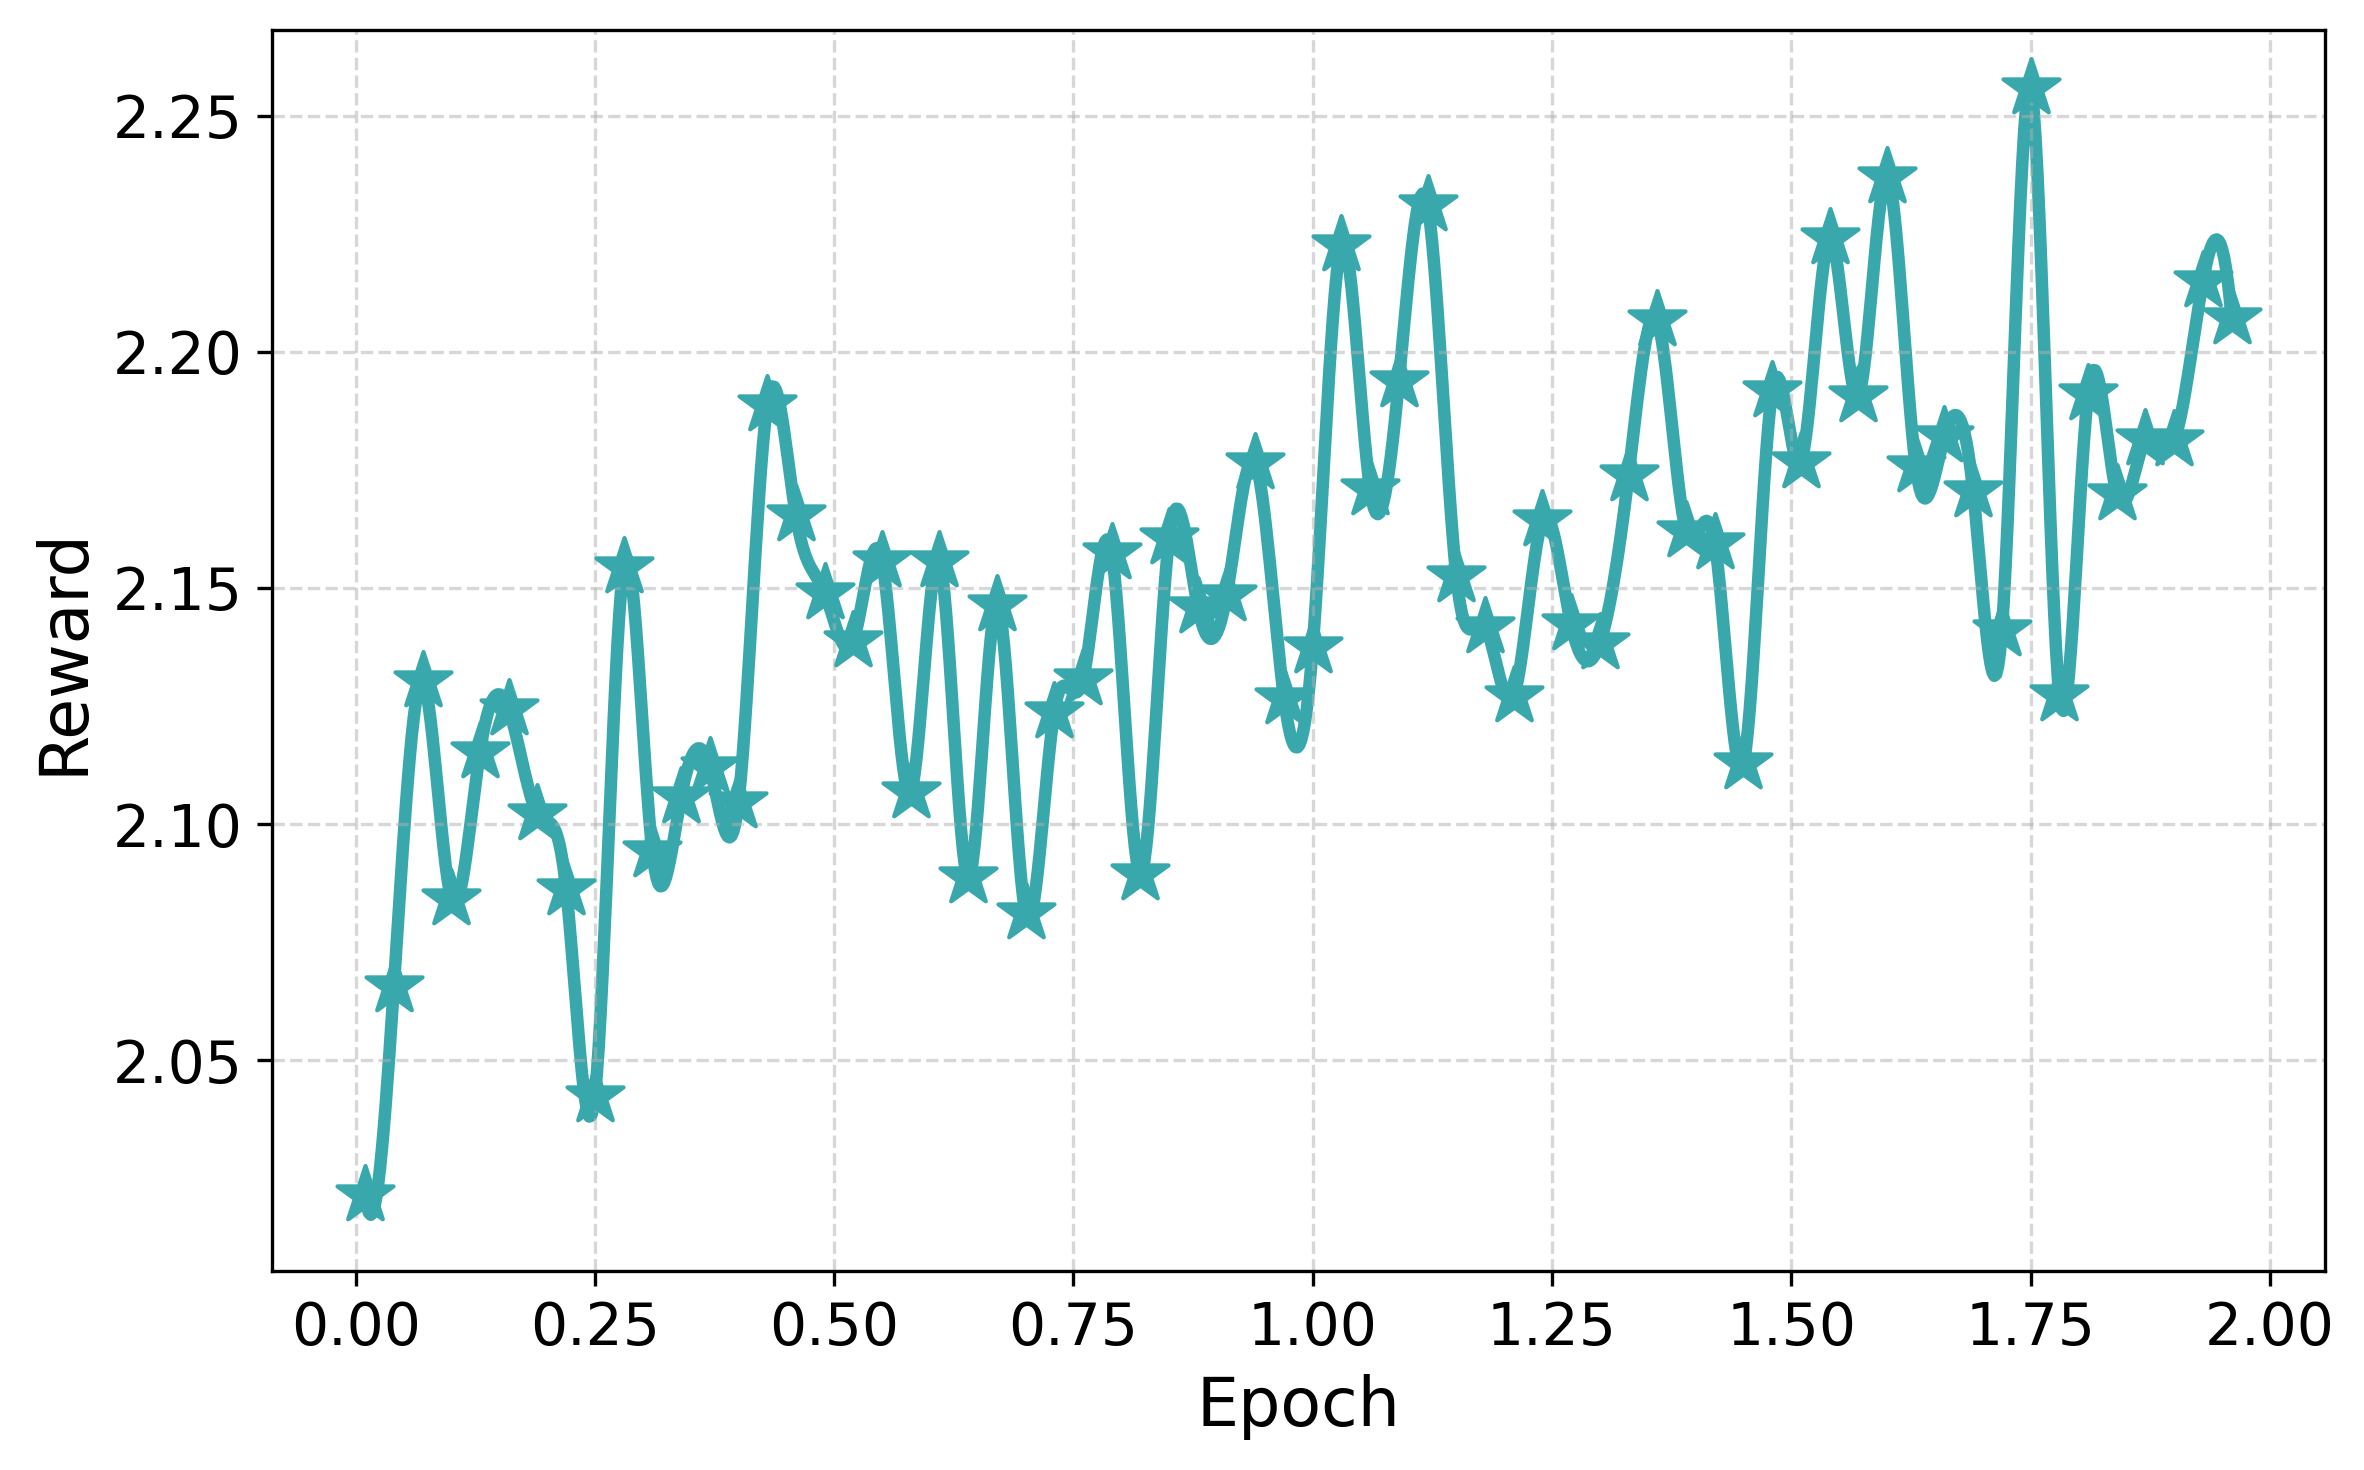

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 假设 avg_reward_per_epoch 已经准备好
x = np.array([d['epoch'] for d in new_avg_reward_per_epoch])
y = np.array([d['avg_reward'] for d in new_avg_reward_per_epoch])

if len(x) > 3:
    xnew = np.linspace(x.min(), x.max(), 1000)   # 关键点
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(xnew)
else:
    xnew, y_smooth = x, y

# 画图
plt.figure(figsize=(8, 5), dpi=300)
# 只改下面两行：颜色和 marker
plt.plot(xnew, y_smooth, color='#38A8AC', linewidth=3, zorder=1)
plt.scatter(x, y, color='#38A8AC', marker='*', s=200, zorder=2)
# plt.plot(xnew, y_smooth, color='#1f77b4', linewidth=3, zorder=1)
# plt.scatter(x, y, color='#1f77b4', marker='*', s=200, zorder=2)

plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Reward', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

plt.savefig("/home/aiqihang.aqh/Appagent/paper/reward_epoch_simple.png")
plt.show()